In [1]:
import matplotlib.pyplot as plt
import radhydropy.utils as ru
from radhydropy.eos import EOS
from radhydropy.fluid import Fluid
from radhydropy.mesh import Mesh
import unyt

I have changed


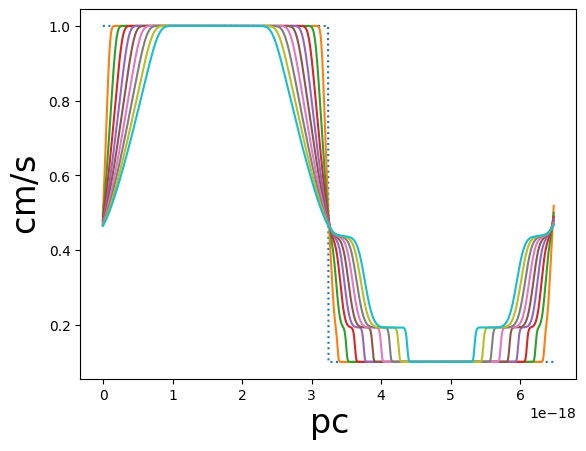

In [2]:
params_sodshock = {
    'coordinate':'cartesian', #
    'EOStype':'polytropic', #type of equation of state (EOS): polytropic or isothermal
    'gamma':5./3., # for polytropic, the polytropic index
    'boxsize':20.0*unyt.cm, # length of the simulation domain
    'timesim':2.0*unyt.s, # total simulation time
    'ngrid':1000, # number of grid to discretize
    'CFL':0.1, # CFL condition for time-step
    'ftype':'sodshock', # initial fluid distribution: uniform, half, gaussian, sodshock
    'tini': 0.*unyt.yr, # initial time
    'rhoini':  1.0 * unyt.g/unyt.cm**3, 
    'vini': 0.0 * unyt.cm/unyt.s,
    'tempini': 1.0 * unyt.g / unyt.cm / unyt.s**2 * (1.28 * unyt.mp) / unyt.kb / (1.0 * unyt.g/unyt.cm**3),
    'boundcond':'Periodic',
    'verbose':0, # speak out details?
    'fixtemp':1, #fix the value of temperature
    'fixvel':1   #fix the value of velocity
}


params_half = {
    'coordinate':'cartesian', #
    'EOStype':'polytropic', #type of equation of state (EOS): polytropic or isothermal
    'gamma':1.4, # for polytropic, the polytropic index
    'boxsize':1.0*unyt.pc, # length of the simulation domain
    'timesim':1.0*unyt.Myr, # total simulation time
    'ngrid':1000, # number of grid to discretize
    'CFL':0.1, # CFL condition for time-step
    'ftype':'gaussian', # initial fluid distribution: uniform, half, gaussian, sodshock
    'tini': 0.*unyt.yr, # initial time
    'rhoini': 1.0 * unyt.mp/ unyt.cm**3, 
    'vini': 1.0 * unyt.km/unyt.s,
    'tempini': 0.1 * unyt.K,
    'boundcond':'Periodic',
    'verbose':0, # speak out details?
    'fixtemp':1, #fix the value of temperature
    'fixvel':1   #fix the value of velocity
}


params = params_sodshock

cave = Mesh(params['boxsize'],params['ngrid'],params['coordinate'])
peos = EOS(params['EOStype'],params['gamma'])
water = Fluid(cave,peos,params['tini'],params['ftype'])
water.SetInitFluid(params['rhoini'],params['vini'],params['tempini'],params['verbose'])
water.SetConserved(verbose=params['verbose'])

#plt.plot(water.mesh.xmesh, water.rho.in_cgs()*water.u.in_cgs())
timecount = 0.0 *unyt.Myr
plt.plot(water.mesh.xmesh.to('pc'), water.rho.in_cgs(),ls='dotted')
while water.time < params['timesim']:
    dt = water.GetTimeStep()
    water.SetBoundary(params['boundcond'])
    water.SetConserved(verbose=params['verbose'])
    water.SetInterFaceFlux(verbose=params['verbose'],order=0)
    water.AddFluxes(dt)
    water.SetPrimitive(verbose=params['verbose'])
    #print('dt',dt)
    timecount += dt
    if timecount > 0.1 *params['timesim']:
        plt.plot(water.mesh.xmesh.to('pc'), water.rho.in_cgs())
        #plt.show()
        timecount *= 0.0
    #plt.plot(water.mesh.xmesh.to('pc'), water.rho.in_cgs())

plt.xlabel(r'$'+water.mesh.xmesh.to('pc').units.latex_repr+'$',fontsize=24)
plt.ylabel(r'$'+water.u.in_cgs().units.latex_repr+'$',fontsize=24)
plt.show()

In [7]:
import unyt
from unyt import dimensions as dim

In [9]:
def CheckDimension(a,dimcheck):
    dummy = a/dimcheck
    pass

In [11]:
time = 1.0 * unyt.Myr

In [12]:
foo(time,unyt.s)